In [4]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


C:\Users\user\AppData\Local\Temp\ipykernel_24304\4002315895.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='directional_size_bytes', data=df, ax=axes[0, 0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_24304\4002315895.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y='src_index', data=df, ax=axes[1, 0], palette='Set2', split=True)


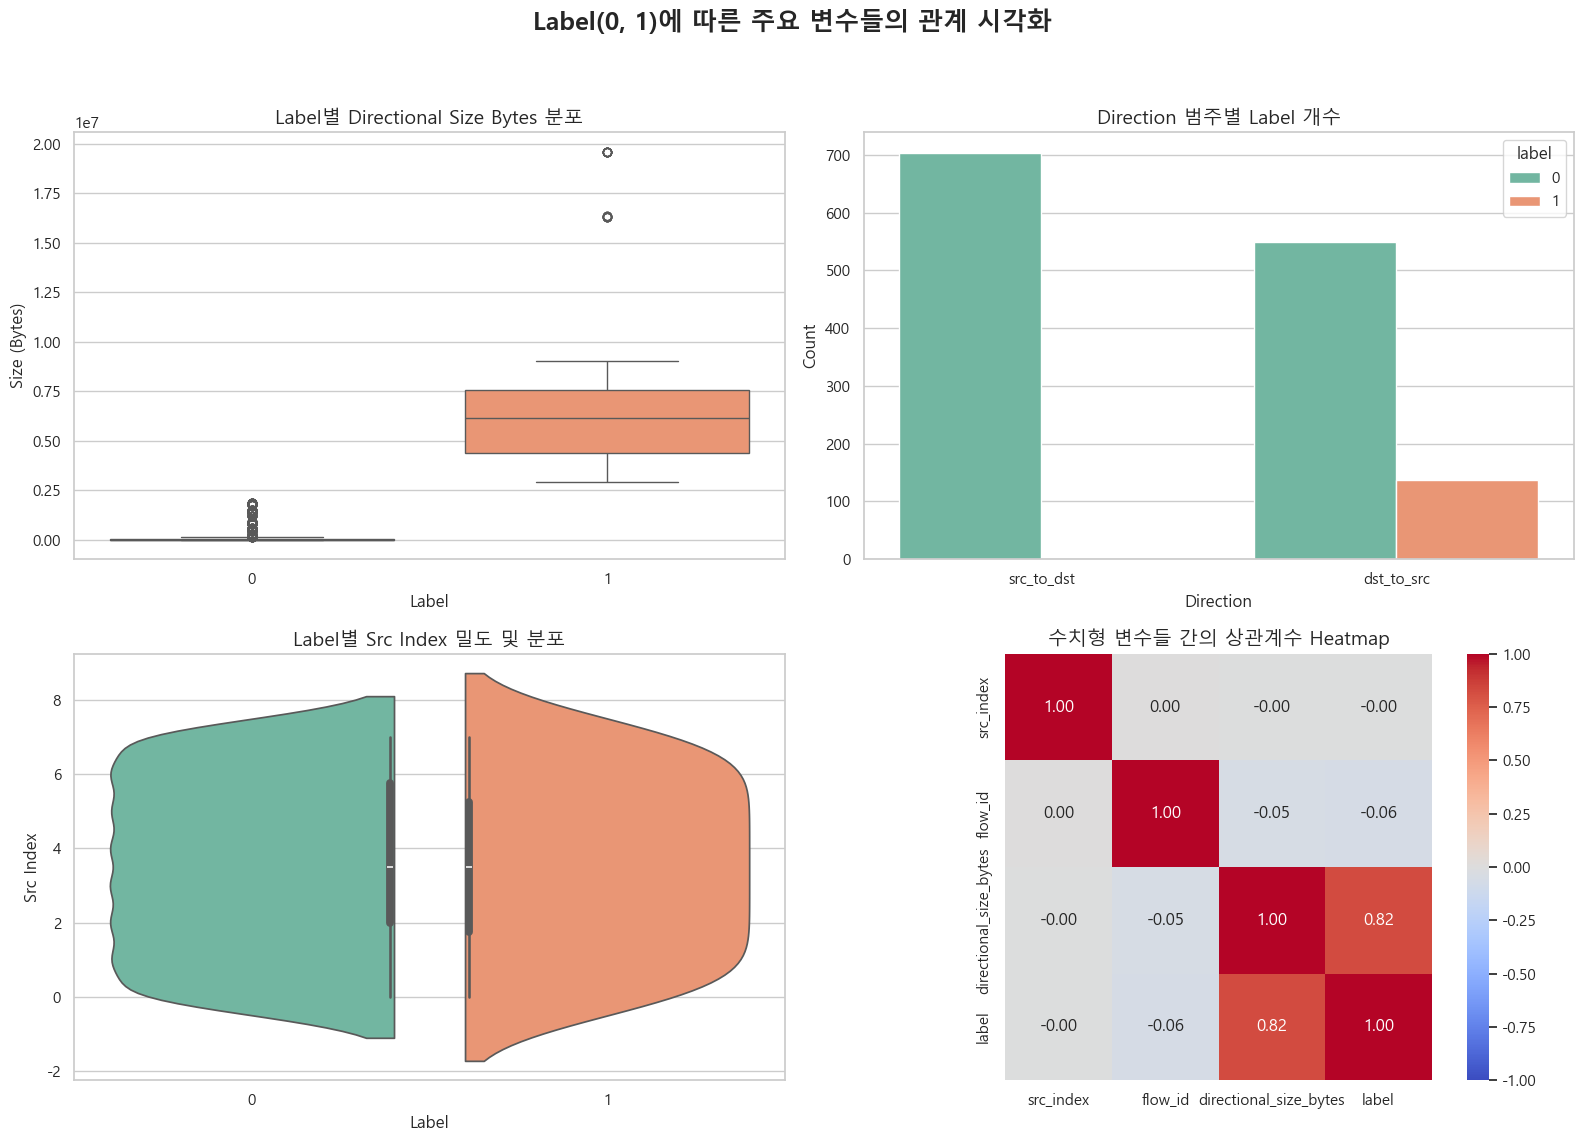

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리 (x 데이터 제외)
data_list = []
file_path = 'dataset.jsonl' # 실제 jsonl 파일 경로로 변경하세요.

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        
        # 중첩된 flow_key 정보를 평탄화하고 x는 제외
        row = {
            'src_index': data['flow_key']['src_index'],
            'flow_id': data['flow_key']['flow_id'],
            'direction': data['flow_key']['direction'],
            'directional_size_bytes': data['directional_size_bytes'],
            'label': data['label']
        }
        data_list.append(row)

# Pandas DataFrame으로 변환
df = pd.DataFrame(data_list)

# 2. 시각화 설정
# 한글 폰트 깨짐 방지 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

# 그래프 레이아웃 설정 (2x2 그리드)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Label(0, 1)에 따른 주요 변수들의 관계 시각화', fontsize=18, fontweight='bold')

# --- [1] directional_size_bytes와 label의 관계 (Boxplot) ---
# 라벨에 따라 데이터 크기(바이트)의 분포가 어떻게 다른지 확인합니다.
sns.boxplot(x='label', y='directional_size_bytes', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Label별 Directional Size Bytes 분포', fontsize=14)
axes[0, 0].set_xlabel('Label')
axes[0, 0].set_ylabel('Size (Bytes)')

# --- [2] direction과 label의 관계 (Countplot) ---
# 패킷 방향(direction) 범주에 따라 라벨의 비율이 어떻게 달라지는지 확인합니다.
sns.countplot(x='direction', hue='label', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Direction 범주별 Label 개수', fontsize=14)
axes[0, 1].set_xlabel('Direction')
axes[0, 1].set_ylabel('Count')

# --- [3] src_index와 label의 관계 (Violin Plot) ---
# src_index의 밀집도와 분포를 라벨별로 비교합니다.
sns.violinplot(x='label', y='src_index', data=df, ax=axes[1, 0], palette='Set2', split=True)
axes[1, 0].set_title('Label별 Src Index 밀도 및 분포', fontsize=14)
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Src Index')

# --- [4] 수치형 변수들 간의 상관관계 (Heatmap) ---
# 수치형 데이터 간의 선형적 상관관계를 한눈에 파악합니다.
numeric_cols = ['src_index', 'flow_id', 'directional_size_bytes', 'label']
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1, 1], vmin=-1, vmax=1, center=0, square=True)
axes[1, 1].set_title('수치형 변수들 간의 상관계수 Heatmap', fontsize=14)

# 레이아웃 간격 조정 및 출력
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_24304\2248345468.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='x_mean', data=df, ax=axes[0], palette='pastel')


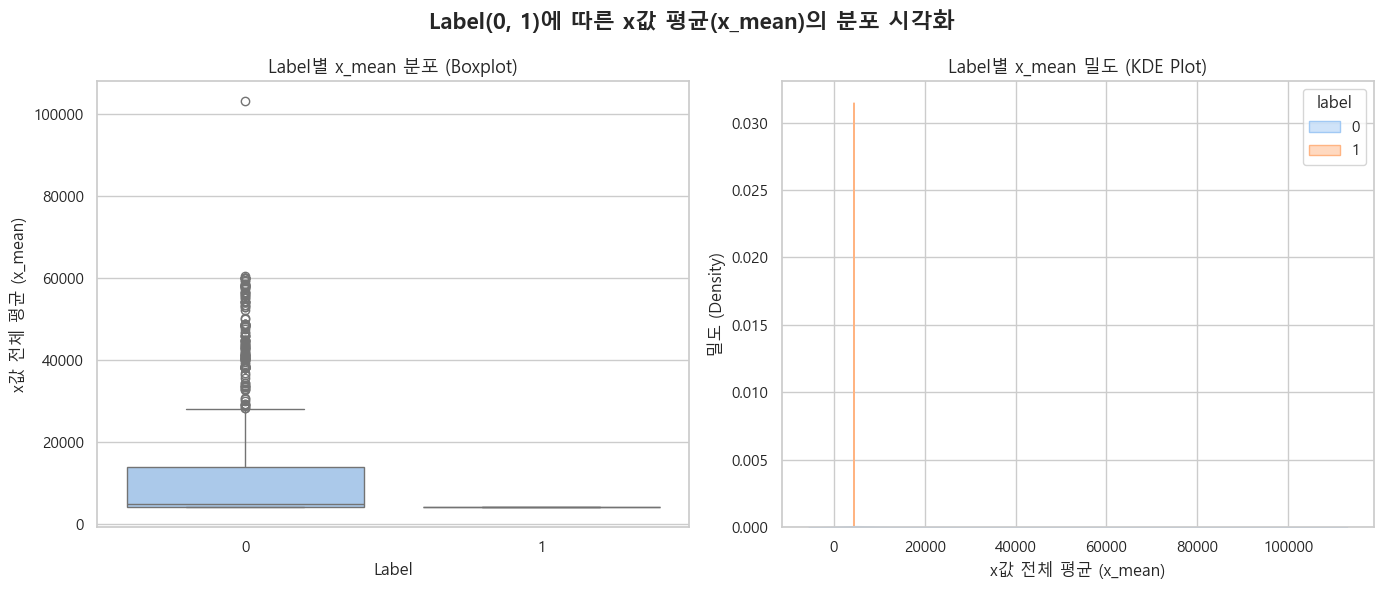

In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 x값 평균 계산
data_list = []
file_path = 'dataset.jsonl' # 실제 파일 경로로 변경하세요.

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        
        # x 데이터를 numpy 배열로 변환 후 전체 요소의 평균 계산
        x_array = np.array(data['x'])
        
        # 배열이 비어있지 않은 경우에만 평균 계산 (안전 장치)
        if x_array.size > 0:
            x_mean = np.mean(x_array)
        else:
            x_mean = 0 
            
        data_list.append({
            'x_mean': x_mean,
            'label': data['label']
        })

# Pandas DataFrame으로 변환
df = pd.DataFrame(data_list)

# 2. 시각화 설정
# 한글 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') # Mac 사용자의 경우 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

# 그래프 레이아웃 설정 (1x2 그리드)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Label(0, 1)에 따른 x값 평균(x_mean)의 분포 시각화', fontsize=16, fontweight='bold')

# --- [1] Boxplot (상자 수염 그림) ---
# 라벨별 x_mean의 중앙값, 사분위수, 이상치(Outlier)를 한눈에 비교합니다.
sns.boxplot(x='label', y='x_mean', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Label별 x_mean 분포 (Boxplot)', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('x값 전체 평균 (x_mean)')

# --- [2] KDE Plot (커널 밀도 추정 그래프) ---
# 라벨별 x_mean이 어떤 값 주변에 밀집해 있는지 부드러운 곡선으로 보여줍니다.
sns.kdeplot(data=df, x='x_mean', hue='label', ax=axes[1], fill=True, common_norm=False, palette='pastel', alpha=0.5)
axes[1].set_title('Label별 x_mean 밀도 (KDE Plot)', fontsize=13)
axes[1].set_xlabel('x값 전체 평균 (x_mean)')
axes[1].set_ylabel('밀도 (Density)')

# 레이아웃 간격 조정 및 출력
plt.tight_layout()
plt.show()

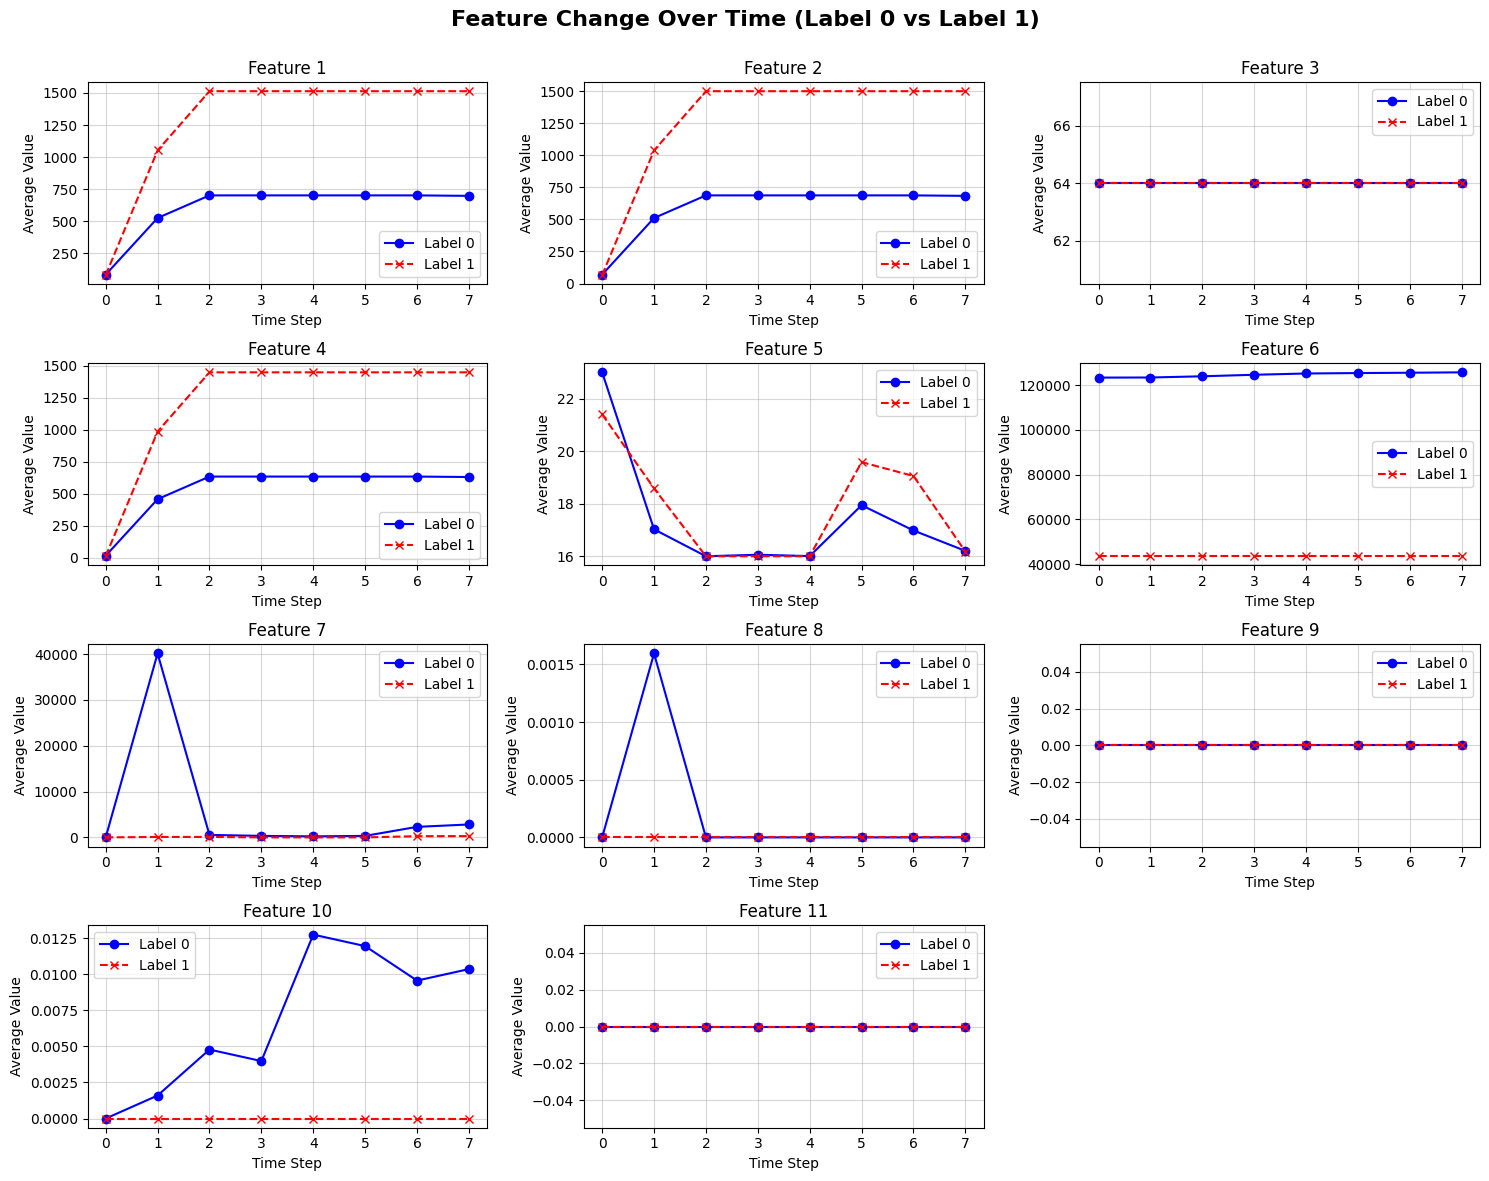

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. 라벨별로 데이터를 담을 리스트 준비
data_label_0 = []
data_label_1 = []

# 2. JSONL 파일 읽기
file_path = 'dataset.jsonl'  # 실제 파일 이름으로 변경하세요.

with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        x_array = np.array(data["x"])
        label = data["label"]
        
        # 라벨에 따라 각각의 리스트에 추가
        if label == 0:
            data_label_0.append(x_array)
        elif label == 1:
            data_label_1.append(x_array)

# 3. 리스트를 numpy 배열로 변환하고, 샘플(row) 단위로 평균 계산
# 변환 후 배열의 형태(shape)는 (샘플 개수, 10(시간), 11(피처))가 됩니다.
# axis=0 으로 평균을 내면 (10, 11) 형태의 평균 데이터가 나옵니다.
avg_x_0 = np.mean(data_label_0, axis=0) 
avg_x_1 = np.mean(data_label_1, axis=0) 

# 4. 11개의 피처를 시각화하기 위해 4x3 형태의 그래프 그리드 생성
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Feature Change Over Time (Label 0 vs Label 1)', fontsize=16, fontweight='bold')

# 11개의 피처 각각에 대해 그래프 그리기
for i in range(11):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # 각 피처의 시간에 따른 평균값 플롯 (avg_x_0[:, i]는 i번째 피처의 모든 시간대 값을 의미함)
    ax.plot(avg_x_0[:, i], label='Label 0', color='blue', marker='o', linestyle='-')
    ax.plot(avg_x_1[:, i], label='Label 1', color='red', marker='x', linestyle='--')
    
    ax.set_title(f'Feature {i+1}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Average Value')
    ax.legend()
    ax.grid(True, alpha=0.5)

# 12번째 빈 그래프 공간은 숨김 처리
axes[3, 2].axis('off')

# 레이아웃 간격 조정 및 출력
plt.tight_layout()
fig.subplots_adjust(top=0.92) # 메인 타이틀과 서브플롯 간의 여백 확보
plt.show()